In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install micropip

,  Downloading micropip-0.9.0-py3-none-any.whl.metadata (21 kB)
,Downloading micropip-0.9.0-py3-none-any.whl (114 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.5 MB/s eta 0:00:00
,Installing collected packages: micropip
,Successfully installed micropip-0.9.0


In [5]:
import micropip
await micropip.install("imbalanced-learn")

In [6]:
import cv2
import numpy as np
import os

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [7]:
def preprocess_image(img):
    img = cv2.resize(img, (128, 128))

    img = cv2.medianBlur(img, 5)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.equalizeHist(gray)

    return img, hsv, gray

In [8]:
def extract_features(img, hsv, gray):
    features = []

    # 1. HSV Hue Histogram
    hist = cv2.calcHist([hsv], [0], None, [32], [0, 180])
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-6)
    features.extend(hist.flatten())

    # 2. Texture (LBP)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    lbp_hist = lbp_hist.astype("float32")
    lbp_hist /= (lbp_hist.sum() + 1e-6)
    features.extend(lbp_hist)

    # 3. Shape Features (SAFE)
    edges = cv2.Canny(gray, 100, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = sum(cv2.contourArea(c) for c in contours)
    perimeter = sum(cv2.arcLength(c, True) for c in contours)

    # Hard safety guards
    area = np.clip(area, 0, 1e5)
    perimeter = np.clip(perimeter, 0, 1e4)

    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    features.extend([area, perimeter, circularity])

    return np.array(features, dtype=np.float32)

In [20]:
base_path = "/content/drive/MyDrive/Data/Data/Train"
def load_dataset(base_path):
    X, y = [], []

    class_map = {"apple": 0, "tomato": 1}

    for cls, label in class_map.items():
        folder = os.path.join(base_path, cls)

        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img, hsv, gray = preprocess_image(img)
            features = extract_features(img, hsv, gray)

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

In [23]:
X, y = load_dataset("/content/drive/MyDrive/Data/Data/Train")
mask = np.isfinite(X).all(axis=1)
X = X[mask]
y = y[mask]

In [24]:
import matplotlib.pyplot as plt

In [28]:
def show_sample_images(base_path, samples=3):
    classes = ["apple", "tomato"]

    plt.figure(figsize=(8, 4))

    idx = 1
    for cls in classes:
        folder = os.path.join(base_path, cls)
        images = os.listdir(folder)[:samples]

        for img_name in images:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(2, samples, idx)
            plt.imshow(img)
            plt.title(cls.capitalize())
            plt.axis("off")
            idx += 1

    plt.suptitle("Apple and Tomato Images", fontsize=14)
    plt.show()

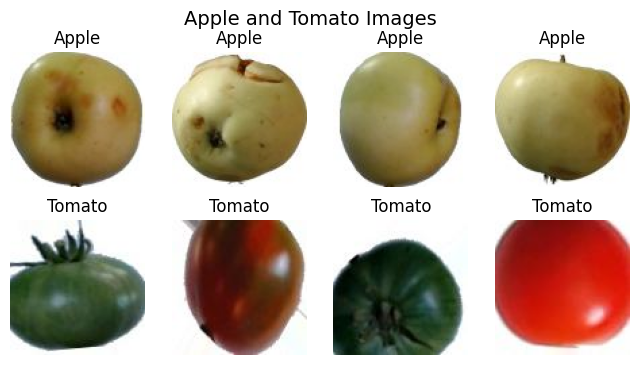

In [30]:
show_sample_images("/content/drive/MyDrive/Data/Data/Train", samples=4)

In [31]:
def show_preprocessing_demo(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img, hsv, gray = preprocess_image(img)
    edges = cv2.Canny(gray, 100, 200)

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale + Equalized")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(hsv[:,:,0], cmap="hsv")
    plt.title("HSV (Hue Channel)")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap="gray")
    plt.title("Edge Detection (Canny)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [45]:


path = "/content/drive/MyDrive/Data/Data/Train/apple"

print(os.listdir(path)[:10])

['apples_13.jpg', 'apples_109.jpg', 'apples_11.jpg', 'apples_102.jpg', 'apples_119.jpg', 'apples_121.jpg', 'apples_140.jpg', 'apples_136.jpg', 'apples_104.jpg', 'apples_105.jpg']


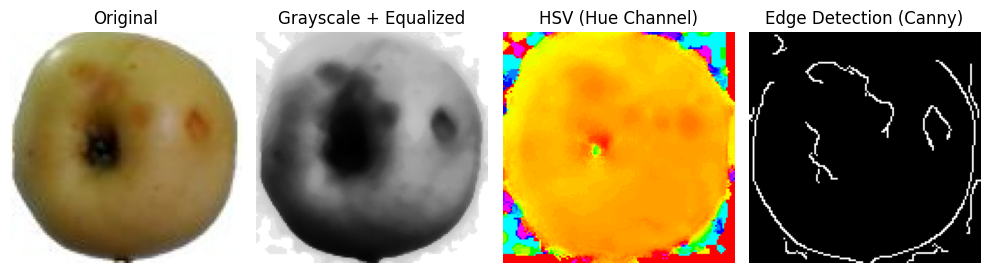

In [46]:
show_preprocessing_demo("/content/drive/MyDrive/Data/Data/Train/apple/apples_13.jpg")

In [47]:


path = "/content/drive/MyDrive/Data/Data/Train/tomato"

print(os.listdir(path)[:10])

['aug_batch13_img14.jpg', 'aug_batch12_img8.jpg', 'aug_batch11_img8.jpg', 'aug_batch12_img14.jpg', 'aug_batch12_img22.jpg', 'aug_batch11_img4.jpg', 'aug_batch12_img25.jpg', 'aug_batch12_img15.jpg', 'aug_batch12_img17.jpg', 'aug_batch12_img18.jpg']


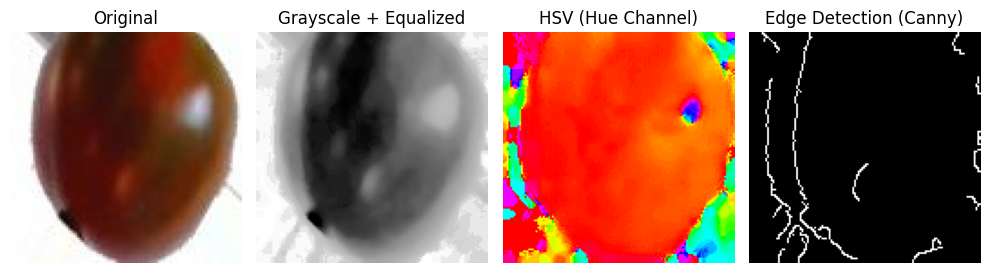

In [49]:
show_preprocessing_demo(
    "/content/drive/MyDrive/Data/Data/Train/tomato/aug_batch12_img8.jpg"
)

In [50]:
def show_contours(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = img.copy()
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title("Contour-Based Shape Features")
    plt.axis("off")
    plt.show()

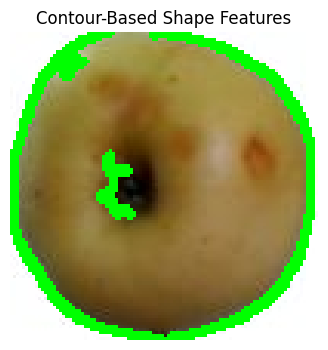

In [52]:
show_contours("/content/drive/MyDrive/Data/Data/Train/apple/apples_13.jpg")

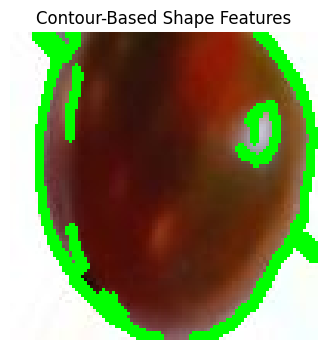

In [51]:
show_contours("/content/drive/MyDrive/Data/Data/Train/tomato/aug_batch12_img8.jpg")

In [54]:
img=cv2.imread("/content/drive/MyDrive/Data/Data/Train/apple/apples_13.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)
sift_img = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

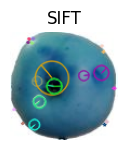

In [55]:
plt.subplot(3,4,12); plt.imshow(sift_img); plt.title("SIFT"); plt.axis('off')

In [56]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42,stratify=y_resampled
)

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import learning_curve

k_values = [3,4,5,6,7,8,9]

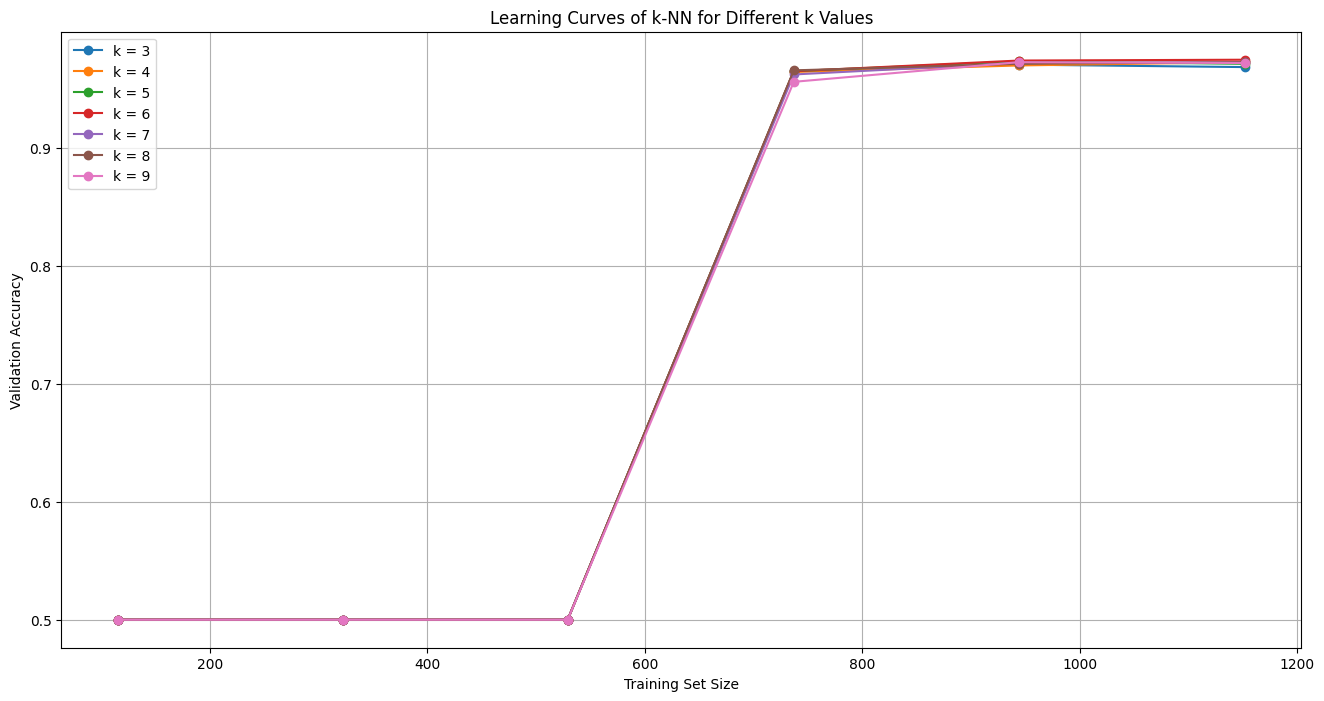

In [58]:
plt.figure(figsize=(16, 8))

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=k,
            weights="distance",
            metric="minkowski"
        ))
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=knn_pipeline,
        X=X_resampled,
        y=y_resampled,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.plot(
        train_sizes,
        val_mean,
        marker="o",
        label=f"k = {k}"
    )

plt.xlabel("Training Set Size")
plt.ylabel("Validation Accuracy")
plt.title("Learning Curves of k-NN for Different k Values")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
k = 4

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance",
            metric="minkowski"))
])
knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Apples", "Tomatoes"]))

Confusion Matrix:
,[[142   2]
, [  2 142]]
,
,Classification Report:
,              precision    recall  f1-score   support
,
,      Apples       0.99      0.99      0.99       144
,    Tomatoes       0.99      0.99      0.99       144
,
,    accuracy                           0.99       288
,   macro avg       0.99      0.99      0.99       288
,weighted avg       0.99      0.99      0.99       288
,


Accuracy:
0.7460035523978685

Confusion Matrix:
[[178 106]
 [ 37 242]]

Classification Report:
              precision    recall  f1-score   support

       Apple       0.83      0.63      0.71       284
      Tomato       0.70      0.87      0.77       279

    accuracy                           0.75       563
   macro avg       0.76      0.75      0.74       563
weighted avg       0.76      0.75      0.74       563



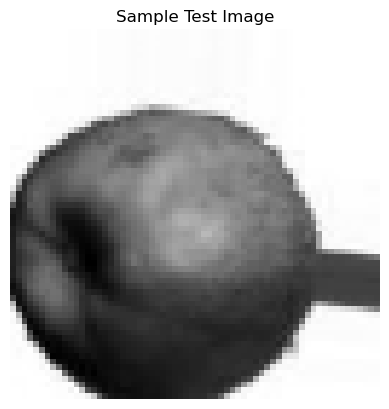

In [1]:
# ==============================
# SIMPLE COMPUTER VISION PROJECT
# ==============================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------
# LOAD DATASET
# ------------------------------

data = []
labels = []

classes = ["apple", "tomato"]

for label, cls in enumerate(classes):

    folder = f"dataset/Train/{cls}"

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        # ------------------------------
        # PREPROCESSING
        # ------------------------------

        img = cv2.resize(img, (64, 64))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ------------------------------
        # DATA AUGMENTATION
        # ------------------------------

        flip = cv2.flip(gray, 1)

        # flatten images
        data.append(gray.flatten())
        labels.append(label)

        data.append(flip.flatten())
        labels.append(label)

# convert to numpy array
X = np.array(data)
y = np.array(labels)

# ------------------------------
# TRAIN TEST SPLIT
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------
# MODEL TRAINING
# ------------------------------

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

# ------------------------------
# PREDICTION
# ------------------------------

y_pred = model.predict(X_test)

# ------------------------------
# EVALUATION
# ------------------------------

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Apple", "Tomato"]
))

# ------------------------------
# SHOW SAMPLE IMAGE
# ------------------------------

plt.imshow(X_test[0].reshape(64,64), cmap="gray")
plt.title("Sample Test Image")
plt.axis("off")
plt.show()